In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from icecube import icetray, dataio, phys_services                                                                        
from icecube import dataclasses  
from matplotlib.colors import LogNorm
from scipy.stats import ks_2samp
import tables
from scipy.stats import kurtosis
from scipy.stats import skew
from scipy.stats import pearsonr
from scipy.stats import iqr
from collections import defaultdict
import pandas as pd

In [2]:
#fCC = tables.open_file('../../dataset_complete/merger/merged_CC_0.h5', mode='r')
#fNC = tables.open_file('../../dataset_complete/merger/merged_NC_0.h5', mode='r')

In [3]:
def get_var_summary(f, var_type):

    if var_type == 'time_residual':
        var = f.root.OMMapReco.col('time_residual') 
    elif var_type == 'distance':
        var = f.root.OMMapReco.col('distance')
    elif var_type == 'angle':
        var = f.root.OMMapReco.col('angle')
    else:
        raise ValueError("Variable type you passed is not valid.")

    # Reading columns
    event_ids = f.root.EventCounter.col('value')
    om_counter = f.root.OMMapReco.col('om_counter')
    energies = f.root.OMMapReco.col('om_renergy')
    charges = f.root.OMMapReco.col('om_total_charge')

    if var_type == 'angle':
        var = np.cos(np.asarray(var))
    else:
        var = np.asarray(var)

    event_ids = np.asarray(event_ids)

    if var_type == 'time residual':
        bool_ = (var>=min_val)&(var<=max_val)
        
        var = var[bool_]
        om_counter = np.asarray(om_counter)[bool_]
        energies = np.asarray(energies)[bool_]
        charges = np.asarray(charges)[bool_]
    else:
        om_counter = np.asarray(om_counter)
        energies = np.asarray(energies)
        charges = np.asarray(charges)
        
    var_summ = []
    
    index_map = defaultdict(list) #making a default dictionary is truly a game changer it is very fast
    for idx, val in enumerate(om_counter):
        index_map[val].append(idx)
        #print(index_map)
    
    # Iterate once
    for counter, event_id in enumerate(event_ids):
        indices = index_map[event_id]
        var_vals = var[indices]
        if len(energies[indices]) != 0:
            #energy_val = energies[indices][0]  # first energy for that event
            #charge_val = charges[indices][0]
    
            var_summ.append((np.mean(var_vals), np.std(var_vals), np.median(var_vals), iqr(var_vals), np.sum(var_vals), 
                               kurtosis(var_vals), skew(var_vals)))#, energy_val, charge_val))
        
        if counter % 10000 == 0:
            print(counter)

    return map(np.array, zip(*var_summ))

In [4]:
def make_dataset(f, interaction_type = 1):
    tres_mean, tres_std, tres_median, tres_iqr, tres_sum, tres_kurtosis, tres_skew = get_var_summary(f, 'time_residual')
    dist_mean, dist_std, dist_median, dist_iqr, dist_sum, dist_kurtosis, dist_skew = get_var_summary(f, 'distance')
    ang_mean, ang_std, ang_median, ang_iqr, ang_sum, ang_kurtosis, ang_skew = get_var_summary(f, 'angle')

    cogDist = np.sqrt((f.root.RecoX.col('value')-f.root.CogX.col('value'))**2+
                    (f.root.RecoY.col('value')-f.root.CogY.col('value'))**2+ 
                    (f.root.RecoZ.col('value')-f.root.CogZ.col('value'))**2)

    if interaction_type == 0:
        index = np.zeros(len(f.root.EventCounter.col('value')))
    else:
        index = np.ones(len(f.root.EventCounter.col('value')))

    data = {"Label": index,
        "EventCounter": f.root.EventCounter.col('value'),
        "RecoEnergy": f.root.RecoEnergy.col('value'),
        "CogDistance": cogDist,
        "TotalmDOMCharge": f.root.TotalmDOMCharge.col('value'),
        "TotalCharge": f.root.TotalCharge.col('value'),
        "Beta1Reco": f.root.Beta1Reco.col('value'),
        "Beta2Reco": f.root.Beta2Reco.col('value'),
        "Beta3Reco": f.root.Beta3Reco.col('value'),
        "Beta4Reco": f.root.Beta4Reco.col('value'),
        "Beta5Reco": f.root.Beta5Reco.col('value'),
        "tres_mean": tres_mean, 
        "tres_std": tres_std, 
        "tres_median": tres_median, 
        "tres_iqr": tres_iqr, 
        "tres_sum": tres_sum, 
        "tres_kurtosis": tres_kurtosis, 
        "tres_skew": tres_skew, 
        #"tres_energy": tres_energy, 
        #"tres_charge_val": tres_charge_val,
        "dist_mean": dist_mean, 
        "dist_std": dist_std, 
        "dist_median": dist_median, 
        "dist_iqr": dist_iqr, 
        "dist_sum": dist_sum, 
        "dist_kurtosis": dist_kurtosis, 
        "dist_skew": dist_skew, 
        #"dist_energy": dist_energy, 
        #"dist_charge_val": dist_charge_val,
        "ang_mean": ang_mean, 
        "ang_std": ang_std, 
        "ang_median": ang_median, 
        "ang_iqr": ang_iqr, 
        "ang_sum": ang_sum, 
        "ang_kurtosis": ang_kurtosis, 
        "ang_skew": ang_skew, 
        #"ang_energy": ang_energy, 
        #"ang_charge_val": ang_charge_val,
        }

    return data

In [5]:
def make_pandas_dataframe(i):

    dfs = []
    
    fCC = tables.open_file(f'../../dataset_complete/merger/merged_CC_{i}.h5', mode='r')
    fNC = tables.open_file(f'../../dataset_complete/merger/merged_NC_{i}.h5', mode='r')
        
    dataCC = make_dataset(fCC, 1)
    dfCC = pd.DataFrame(dataCC)
    dfs.append(dfCC)
        
    dataNC = make_dataset(fNC, 0)
    dfNC = pd.DataFrame(dataNC)
    dfs.append(dfNC)

    combined_df = pd.concat(dfs)
    shuffled_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

    return shuffled_df

In [7]:
all_dfs = make_pandas_dataframe(0)

0


/tmp/ipykernel_6401/3207362271.py:53: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis(var_vals), skew(var_vals)))#, energy_val, charge_val))


10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
210000
220000
230000
240000
250000
260000
270000
280000
290000
300000
310000
320000
330000
340000
350000
360000
0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
210000
220000
230000
240000
250000
260000
270000
280000
290000
300000
310000
320000
330000
340000
350000
360000
0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
210000
220000
230000
240000
250000
260000
270000
280000
290000
300000
310000
320000
330000
340000
350000
360000


In [14]:
all_dfs

,Label,EventCounter,RecoEnergy,CogDistance,TotalmDOMCharge,TotalCharge,Beta1Reco,Beta2Reco,Beta3Reco,Beta4Reco,...,dist_sum,dist_kurtosis,dist_skew,ang_mean,ang_std,ang_median,ang_iqr,ang_sum,ang_kurtosis,ang_skew
0,0.0,2.000130e+10,10.623629,28.713482,59.516229,108.486214,0.000757,0.000353,0.000195,0.000169,...,2064.267736,1.184842,1.308856,0.745068,0.270318,0.907417,0.470623,43.213949,-0.865885,-0.733902
1,0.0,2.000077e+10,2.972347,21.388628,9.599285,20.059771,0.012109,0.006900,0.017339,0.008533,...,393.120464,-0.137027,1.204476,0.527560,0.337222,0.735075,0.607969,5.275603,-1.632799,-0.405357
2,0.0,2.000027e+10,15.170857,22.222970,51.691268,88.554933,0.000486,0.000112,0.000160,0.000111,...,1919.147252,2.800677,1.753512,0.599111,0.359360,0.711042,0.558887,35.347562,-0.016509,-0.970127
3,0.0,2.000018e+10,8.847332,39.527689,6.783645,22.808963,0.056038,0.037634,0.029775,0.026322,...,362.171295,-1.026575,-0.661160,0.681736,0.143169,0.729742,0.248170,5.453887,-1.431637,-0.287350
4,0.0,2.000140e+10,4.198339,41.927520,8.775378,20.159060,0.027054,0.006980,-0.000565,0.002520,...,547.241831,-0.654194,0.792194,0.738297,0.189146,0.785954,0.378015,7.382966,-1.756292,-0.187387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480163,0.0,2.000012e+10,4.229039,12.678724,21.113550,42.839713,0.002861,0.001292,0.001061,0.000875,...,590.273014,0.598505,1.352899,0.507125,0.479520,0.722645,0.799593,11.156757,-0.771105,-0.787164
480164,0.0,2.000082e+10,2.133889,32.190822,4.406138,8.192715,0.279089,0.104648,-0.034987,-0.086941,...,157.277552,-1.377881,-0.315680,0.838682,0.087316,0.830189,0.095232,3.354727,-1.116921,0.268330
480165,0.0,2.000039e+10,8.628593,15.289656,5.737678,14.632267,0.006300,-0.001456,0.015315,-0.005685,...,203.315203,-0.321082,0.629837,0.325880,0.419475,0.154437,0.660015,1.955282,-1.371860,0.582263
480166,0.0,2.000041e+10,5.233511,9.796998,28.429536,51.667863,0.000122,0.000334,0.000517,0.000007,...,913.915230,-0.502195,0.467729,0.077876,0.520422,0.186658,0.466745,2.180527,-0.531226,-0.628398


In [13]:
all_dfs.to_hdf('../../dataset_complete/BDT/BDT_0.h5', key='people', mode='w')

In [17]:
df_loaded = pd.read_hdf('../../dataset_complete/BDT/BDT_all.h5', key='data')

In [18]:
df_loaded

,Label,EventCounter,RecoEnergy,CogDistance,TotalmDOMCharge,TotalCharge,Beta1Reco,Beta2Reco,Beta3Reco,Beta4Reco,...,dist_sum,dist_kurtosis,dist_skew,ang_mean,ang_std,ang_median,ang_iqr,ang_sum,ang_kurtosis,ang_skew
0,0.0,2.000034e+10,3.734664,20.381536,1.767075,9.634213,-0.152704,-0.120796,-0.226170,0.111588,...,135.011676,-1.500000,0.267940,0.269216,0.598510,0.665653,0.647649,0.807647,-1.500000,-0.702951
1,0.0,2.000068e+10,9.475776,12.506692,72.356105,108.627380,0.000193,0.000029,0.000012,0.000035,...,1793.407223,2.737424,1.401492,0.273943,0.478699,0.169345,0.996992,17.806267,-1.723687,0.017735
2,0.0,2.000017e+10,11.598042,29.529109,39.816124,58.989796,0.001217,0.000045,0.000116,0.000163,...,1526.042426,6.316891,2.344958,-0.292059,0.394224,-0.187163,0.510396,-10.514125,-0.998126,-0.492746
3,1.0,1.000040e+10,33.671581,31.528053,219.164630,375.943316,0.000028,0.000004,0.000002,0.000003,...,10538.471562,2.129114,1.160814,0.489708,0.386627,0.610043,0.318481,111.163798,0.919681,-1.244435
4,0.0,2.000014e+10,3.504687,17.691622,4.056962,16.009891,0.090123,0.047610,0.034827,0.025211,...,138.736021,-1.500019,0.567185,0.801216,0.198335,0.897202,0.219913,4.807294,-0.447691,-1.043214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1867982,0.0,2.000012e+10,4.229039,12.678724,21.113550,42.839713,0.002861,0.001292,0.001061,0.000875,...,590.273014,0.598505,1.352899,0.507125,0.479520,0.722645,0.799593,11.156757,-0.771105,-0.787164
1867983,0.0,2.000026e+10,10.162115,47.241226,13.874255,26.765127,0.012235,0.002216,-0.001387,-0.000867,...,872.063050,-1.433607,0.292201,-0.322954,0.446502,-0.369443,0.710683,-4.521356,-0.922903,0.268323
1867984,0.0,2.000039e+10,8.628593,15.289656,5.737678,14.632267,0.006300,-0.001456,0.015315,-0.005685,...,203.315203,-0.321082,0.629837,0.325880,0.419475,0.154437,0.660015,1.955282,-1.371860,0.582263
1867985,0.0,2.000017e+10,10.726761,28.560761,17.494355,37.278028,0.004943,0.001045,0.000471,0.000790,...,770.370153,0.322491,0.911972,0.351446,0.363241,0.551764,0.440469,7.028925,-0.439801,-0.656577


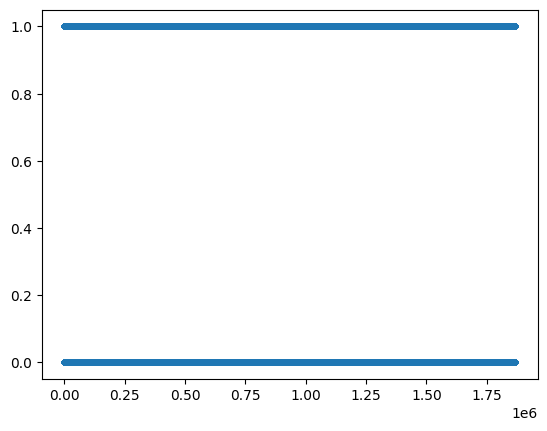

Closing remaining open files:../../dataset_complete/merger/merged_NC_0.h5...done../../dataset_complete/merger/merged_CC_0.h5...done


In [19]:
plt.plot(df_loaded.Label, '.')

In [5]:
dataCC = make_pandas_dataset(fCC, 1)

0


/tmp/ipykernel_4990/257527147.py:53: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis(var_vals), skew(var_vals)))#, energy_val, charge_val))


1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
100000
101000
102000
103000
104000
105000
106000
107000
108000
109000
110000
111000
112000
113000
114000
115000
116000
117000
118000
119000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000


In [10]:
dfCC = pd.DataFrame(dataCC)

In [11]:
dfCC

,Index,EventCounter,RecoEnergy,CogDistance,TotalmDOMCharge,TotalCharge,Beta1Reco,Beta2Reco,Beta3Reco,Beta4Reco,...,dist_sum,dist_kurtosis,dist_skew,ang_mean,ang_std,ang_median,ang_iqr,ang_sum,ang_kurtosis,ang_skew
0,1.0,1.000000e+10,2.615823,27.530403,4.735583,18.871667,0.136683,0.031923,-0.023189,-0.015044,...,185.460882,-0.804990,0.844312,0.702256,0.303460,0.899246,0.626196,3.511280,-1.819678,-0.384372
1,1.0,1.000000e+10,3.544527,25.394303,10.784796,23.042227,0.007848,-0.001211,-0.001317,0.000044,...,507.372878,1.515095,1.562166,0.393111,0.436600,0.575470,0.647328,5.110440,-0.590689,-0.756310
2,1.0,1.000000e+10,13.317755,16.145680,100.639667,175.708428,0.000121,0.000041,0.000007,0.000015,...,3464.839558,1.668189,1.312134,0.523695,0.491858,0.671879,0.447727,50.274723,1.689903,-1.556067
3,1.0,1.000000e+10,6.092452,27.148045,11.072428,26.511133,0.010214,0.000999,0.002400,0.000123,...,472.071727,-0.358061,0.755108,0.362490,0.583361,0.557269,0.859120,4.349882,-0.916145,-0.746517
4,1.0,1.000000e+10,2.795805,34.138788,13.651944,21.791213,0.018317,0.012627,0.007622,0.004448,...,561.404873,-1.595188,0.304066,0.694637,0.129321,0.676093,0.173310,9.724917,-0.724476,-0.161351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119586,1.0,1.000012e+10,3.753301,9.491573,22.602377,40.910916,0.001433,0.000422,-0.000021,0.000322,...,708.681981,-0.219051,0.615390,0.374983,0.487590,0.620514,0.778939,8.624609,-0.743946,-0.938104
119587,1.0,1.000013e+10,45.050861,47.502554,89.228696,182.626994,0.000261,0.000097,0.000025,0.000009,...,5545.344101,0.589522,1.019674,-0.088133,0.429739,-0.085411,0.704525,-8.548907,-1.083446,-0.165253
119588,1.0,1.000013e+10,2.987700,20.211649,11.862154,25.351922,0.010990,0.002064,0.000004,0.001915,...,456.551041,-0.065520,1.107410,0.611284,0.397510,0.841478,0.521386,7.335411,-0.479592,-0.895649
119589,1.0,1.000013e+10,9.391538,30.345234,27.448733,64.299965,0.001943,0.000674,0.000490,0.000551,...,1324.694978,0.396540,0.576742,0.379917,0.362147,0.325949,0.562427,11.777431,0.838891,-0.943035


In [12]:
dataNC = make_pandas_dataset(fNC, 0)

0


/tmp/ipykernel_4990/257527147.py:53: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis(var_vals), skew(var_vals)))#, energy_val, charge_val))


1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
100000
101000
102000
103000
104000
105000
106000
107000
108000
109000
110000
111000
112000
113000
114000
115000
116000
117000
118000
119000
120000
121000
122000
123000
124000
125000
126000
127000
128000
129000
130000
131000
132000
133000
134000
135000
136000
137000
138000
139000
140000
141000
142000
143000
144000
145000
146000
147000
148000
149000
150000
151000
152000
153000
154000
155000
156000
157000
158000
15

In [13]:
dfNC = pd.DataFrame(dataNC)

In [14]:
dfNC

,Index,EventCounter,RecoEnergy,CogDistance,TotalmDOMCharge,TotalCharge,Beta1Reco,Beta2Reco,Beta3Reco,Beta4Reco,...,dist_sum,dist_kurtosis,dist_skew,ang_mean,ang_std,ang_median,ang_iqr,ang_sum,ang_kurtosis,ang_skew
0,0.0,2.000072e+10,1.848572,17.270479,4.432712,8.414994,0.057984,0.010387,-0.007751,0.005217,...,142.857378,0.489809,1.294704,0.700243,0.257152,0.762499,0.177082,4.901704,0.865729,-1.371081
1,0.0,2.000072e+10,2.216394,33.756244,2.821701,13.439169,0.000102,-0.004199,0.069901,-0.028560,...,195.458055,-1.591445,-0.277192,0.323891,0.393236,0.359799,0.573947,1.295565,-1.475925,-0.191953
2,0.0,2.000072e+10,3.141459,15.576427,3.457547,10.580292,-0.421598,-0.050944,0.024581,0.161073,...,102.341310,-1.500000,-0.243696,0.089636,0.725767,0.158340,0.886885,0.268908,-1.500000,-0.141147
3,0.0,2.000072e+10,6.290730,20.414902,23.290932,39.507673,0.000857,0.000053,0.000021,0.000270,...,973.472620,-0.886780,0.393511,0.355196,0.366305,0.392573,0.485373,8.169497,-0.400993,-0.715582
4,0.0,2.000072e+10,17.128397,22.329311,170.035742,291.758959,0.000040,0.000006,0.000002,0.000005,...,6423.994405,1.412698,1.171095,0.514966,0.457042,0.686907,0.351462,84.969449,2.579223,-1.799881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360572,0.0,2.000089e+10,2.085253,4.923291,6.119857,10.961627,0.117521,0.082940,0.055811,0.041255,...,33.665800,1.103160,1.738210,0.476888,0.090153,0.512420,0.020568,2.861331,1.093573,-1.728812
360573,0.0,2.000089e+10,2.400967,20.196498,4.712574,7.016615,0.142815,0.043603,-0.013832,-0.017343,...,106.340416,-0.073153,1.261581,0.621497,0.329336,0.749235,0.255873,3.107487,-0.211607,-1.179411
360574,0.0,2.000089e+10,2.948915,14.624612,3.906766,16.425365,0.177982,0.056747,0.077846,0.070874,...,85.836909,-0.676466,1.141165,0.351275,0.405384,0.566584,0.248165,1.405100,-0.674653,-1.143772
360575,0.0,2.000089e+10,15.898366,38.070097,7.198225,30.409455,0.064973,0.050148,0.034530,0.022122,...,326.747628,2.071191,1.888672,0.258244,0.244419,0.236286,0.376510,2.065955,-1.232958,-0.165190


In [17]:
combined_df = pd.concat([dfCC, dfNC])

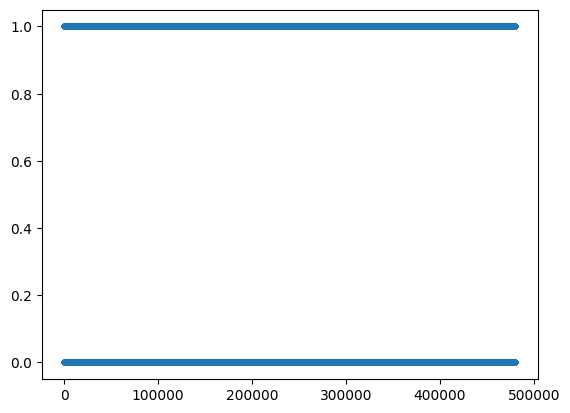

In [29]:
plt.plot(combined_df.sample(frac=1, random_state=0).reset_index(drop=True).Index, '.')

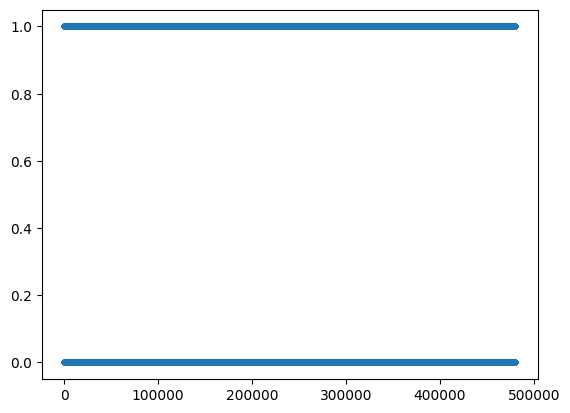

In [30]:
plt.plot(combined_df.sample(frac=1).reset_index(drop=True).Index, '.')

In [ ]:
tres_meanCC, tres_stdCC, tres_medianCC, tres_iqrCC, tres_sumCC, tres_kurtosisCC, tres_skewCC, tres_energyCC, tres_charge_valCC = get_var_summary(fCC, 'time_residual')
tres_meanNC, tres_stdNC, tres_medianNC, tres_iqrNC, tres_sumNC, tres_kurtosisNC, tres_skewNC, tres_energyNC, tres_charge_valNC = get_var_summary(fNC, 'time_residual')

In [ ]:
dist_meanCC, dist_stdCC, dist_medianCC, dist_iqrCC, dist_sumCC, dist_kurtosisCC, dist_skewCC, dist_energyCC, dist_charge_valCC = get_var_summary(fCC, 'distance')
dist_meanNC, dist_stdNC, dist_medianNC, dist_iqrNC, dist_sumNC, dist_kurtosisNC, dist_skewNC, dist_energyNC, dist_charge_valNC = get_var_summary(fNC, 'distance')

In [ ]:
ang_meanCC, ang_stdCC, ang_medianCC, ang_iqrCC, ang_sumCC, ang_kurtosisCC, ang_skewCC, ang_energyCC, ang_charge_valCC = get_var_summary(fCC, 'angle')
ang_meanNC, ang_stdNC, ang_medianNC, ang_iqrNC, ang_sumNC, ang_kurtosisNC, ang_skewNC, ang_energyNC, ang_charge_valNC = get_var_summary(fNC, 'angle')

In [ ]:
cogDistCC = np.sqrt((fCC.root.RecoX.col('value')-fCC.root.CogX.col('value'))**2+
                    (fCC.root.RecoY.col('value')-fCC.root.CogY.col('value'))**2+ 
                    (fCC.root.RecoZ.col('value')-fCC.root.CogZ.col('value'))**2)

cogDistNC = np.sqrt((fNC.root.RecoX.col('value')-fNC.root.CogX.col('value'))**2+
                    (fNC.root.RecoY.col('value')-fNC.root.CogY.col('value'))**2+
                    (fNC.root.RecoZ.col('value')-fNC.root.CogZ.col('value'))**2)

In [ ]:
indexCC = np.ones(len(fCC.root.EventCounter.col('value')))
indexNC = np.zeros(len(fNC.root.EventCounter.com('value'))) 

In [ ]:
data = {"Index": indexCC,
        "EventCounter": fCC.root.EventCounter.col('value'),
        "RecoEnergy": fCC.root.RecoEnergy.col('value'),
        "CogDistance": cogDistCC,
        "TotalmDOMCharge": fCC.root.TotalmDOMCharge.col('value'),
        "TotalCharge": fCC.root.TotalCharge.col('value'),
        "Beta1Reco": fCC.root.Beta1Reco.col('value'),
        "Beta2Reco": fCC.root.Beta2Reco.col('value'),
        "Beta3Reco": fCC.root.Beta3Reco.col('value'),
        "Beta4Reco": fCC.root.Beta4Reco.col('value'),
        "Beta5Reco": fCC.root.Beta5Reco.col('value'),
        "tres_mean": tres_meanCC , 
        "tres_std": tres_stdCC, 
        "tres_median": tres_medianCC, 
        "tres_iqr": tres_iqrCC, 
        "tres_sum": tres_sumCC, 
        "tres_kurtosis": tres_kurtosisCC, 
        "tres_skew": tres_skewCC, 
        "tres_energy": tres_energyCC, 
        "tres_charge_val": tres_charge_valCC,
        "dist_mean": dist_meanCC , 
        "dist_std": dist_stdCC, 
        "dist_median": dist_medianCC, 
        "dist_iqr": dist_iqrCC, 
        "dist_sum": dist_sumCC, 
        "dist_kurtosis": dist_kurtosisCC, 
        "dist_skew": dist_skewCC, 
        "dist_energy": dist_energyCC, 
        "dist_charge_val": dist_charge_valCC
        "ang_mean": ang_meanCC , 
        "ang_std": ang_stdCC, 
        "ang_median": ang_medianCC, 
        "ang_iqr": ang_iqrCC, 
        "ang_sum": ang_sumCC, 
        "ang_kurtosis": ang_kurtosisCC, 
        "ang_skew": ang_skewCC, 
        "ang_energy": ang_energyCC, 
        "ang_charge_val": ang_charge_valCC,
        }

In [9]:
data = {"om_counter": fCC.root.OMMapReco.col('om_counter'),
        "om_renergy": fCC.root.OMMapReco.col('om_renergy'),
        "om_total_charge": fCC.root.OMMapReco.col('om_total_charge'),
        "hit_charge": fCC.root.OMMapReco.col('hit_charge'),
        "distance": fCC.root.OMMapReco.col('distance'),
        "time_residual": fCC.root.OMMapReco.col('time_residual'),
        "angle": fCC.root.OMMapReco.col('angle'),
        "EventCounter": fCC.root.EventCounter.col('value'),
        "RecoEnergy": fCC.root.RecoEnergy.col('value'),
        "CogDistance": cogDistCC,
        "TotalmDOMCharge": fCC.root.TotalmDOMCharge.col('value'),
        "TotalCharge": fCC.root.TotalCharge.col('value'),
        "Beta1Reco": fCC.root.Beta1Reco.col('value'),
        "Beta2Reco": fCC.root.Beta2Reco.col('value'),
        "Beta3Reco": fCC.root.Beta3Reco.col('value'),
        "Beta4Reco": fCC.root.Beta4Reco.col('value'),
        "Beta5Reco": fCC.root.Beta5Reco.col('value'),
        }

/ (RootGroup) ''
  children := ['Azimuth' (Table), 'Beta1' (Table), 'Beta1Reco' (Table), 'Beta2' (Table), 'Beta2Reco' (Table), 'Beta3' (Table), 'Beta3Reco' (Table), 'Beta4' (Table), 'Beta4Reco' (Table), 'Beta5' (Table), 'Beta5Reco' (Table), 'CogX' (Table), 'CogY' (Table), 'CogZ' (Table), 'EventCounter' (Table), 'Inelasticity' (Table), 'OMMapReco' (Table), 'OMMapTrue' (Table), 'PrimaryEnergy' (Table), 'RecoDirX' (Table), 'RecoDirY' (Table), 'RecoDirZ' (Table), 'RecoEnergy' (Table), 'RecoVertexTime' (Table), 'RecoX' (Table), 'RecoY' (Table), 'RecoZ' (Table), 'SecondaryEnergy' (Table), 'TotalCharge' (Table), 'TotalmDOMCharge' (Table), 'TrueTime' (Table), 'TrueX' (Table), 'TrueY' (Table), 'TrueZ' (Table), 'Zenith' (Table), 'filename' (UnImplemented)]

In [10]:
(fCC.root.Beta1Reco.col('value'))

array([1.36682647e-01, 7.84797395e-03, 1.20945096e-04, ...,
       1.09901665e-02, 1.94343246e-03, 6.50828485e-02])

In [11]:
fCC.root.OMMapReco.col

<bound method Table.col of /OMMapReco (Table(6510398,)) ''
  description := {
  "Run": UInt32Col(shape=(), dflt=0, pos=0),
  "Event": UInt32Col(shape=(), dflt=0, pos=1),
  "SubEvent": UInt32Col(shape=(), dflt=0, pos=2),
  "SubEventStream": EnumCol(enum=Enum({'InIceSplit': 0}), dflt='InIceSplit', base=Int32Atom(shape=(), dflt=0), shape=(), pos=3),
  "exists": UInt8Col(shape=(), dflt=0, pos=4),
  "vector_index": UInt64Col(shape=(), dflt=0, pos=5),
  "angle": Float64Col(shape=(), dflt=0.0, pos=6),
  "distance": Float64Col(shape=(), dflt=0.0, pos=7),
  "hit_charge": Float64Col(shape=(), dflt=0.0, pos=8),
  "hit_time": Float64Col(shape=(), dflt=0.0, pos=9),
  "hx": Float64Col(shape=(), dflt=0.0, pos=10),
  "hy": Float64Col(shape=(), dflt=0.0, pos=11),
  "hz": Float64Col(shape=(), dflt=0.0, pos=12),
  "om_counter": Float64Col(shape=(), dflt=0.0, pos=13),
  "om_penergy": Float64Col(shape=(), dflt=0.0, pos=14),
  "om_renergy": Float64Col(shape=(), dflt=0.0, pos=15),
  "om_senergy": Float64Col(